<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:50px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Overscan
  </span>
</h1>

The overscan region of a CCD, if present, is a part of the chip that is covered. Depending on the camera, it can be a useful way to remove small variations in the bias level from frame to frame.

However, whether or not the overscan is useful depends on the camera. It’s advisable to examine the overscan part of the camera you’re using before deciding if you should include it in image reduction.

One important note: <u>overscan always includes bias, read noise, and dark current.</u> The overscan pixels are still pixels, and just like any other pixel includes dark current and is subject to read noise. Many sources describe overscan as correcting for bias, but if the dark current for the camera is negligible, as it often is for cryogenically cooled cameras, then the overscan is essentially bias.

*Serve para remover pequenas variações no nível de bias de uma imagem pra outra. O nível de bias pode variar um pouco entre frames, e o overscan ajuda a ajustar isso.*

The read noise in the overscan is reduced by averaging over the overscan region. That will be covered in a later notebook; this notebook focuses on <u>what the overscan looks like and how to decide whether or not to use it.</u>

In this notebook we will look at the overscan region for two different cameras, a cryogenically cooled camera in which the overscan provides useful information and a thermo-electrically cooled camera in which the overscan does not provide useful information.

*Se a dark current for negligenciável (câmeras criogenicamente resfriadas), aí o overscan é essencialmente bias. Caso contrário, o overscan tem dark current também.*

In [11]:
from pathlib import Path #biblioteca padrão do Python para trabalhar com caminhos de arquivos (pastas e arquivos no computador).

from astropy.nddata import CCDData #armazenar dados de CCD, ler e guardar imagens FITS com metadados
from astropy.visualization import hist #histogramas
from ccdproc import subtract_overscan 
#função principal deste notebook: calcula o valor médio (ou mediana) da região de overscan e subtrai esse valor de toda a imagem, é da biblioteca ccdproc
import matplotlib.pyplot as plt #plot de gráfico

from convenience_functions import show_image

# Use custom style for larger fonts and figures
plt.style.use('guide.mplstyle')

# Case 1: Cryogenically cooled Large Format Camera (LFC) at Palomar

The images below are from chip 0 of the LFC at the Palomar 200-inch telescope. Technical information about the camera is [here.](https://sites.astro.caltech.edu/palomar/observer/200inchResources/lfcspecs.html) It turns out that the images are not actually 2048 × 4096; as you can see below, the images are 2080 × 4128. The “extra” in each direction is overscan.

The FITS header for these files includes the <u>keyword <span style="color: #d62495">BIASSEC</span>, which indicates the nominal extent of the overscan region.</u> Its value is <span style="color: #d62495"> [2049:2080,1:4127]</span>, which indicates the overscan extends from 2048 to 2079 <u>(Python indexing starts at 0, not 1 like in FITS)</u> in the “short” direction and over the entire chip in the other direction. As we’ll see shortly, the useful overscan region is smaller than this.

We’ll focus here on the overscan in the side that is nominally 2048 wide; in Python that’s the second index. The pixel count cross-sections plotted below are from a bias, science, and flat image. Flat images are particularly helpful in evaluating how much of the overscan region is useful because the average pixel value in the exposed part of the camera is typically large.

In [14]:
cryo_path = Path('example-cryo-LFC') #cria um objeto Path apontando para a pasta example-cryo-LFC, é onde estão os arquivos FITS da câmera LFC

bias_lfc = CCDData.read(cryo_path / 'ccd.001.0.fits', unit='count') #lê a imagem de bias (exposição zero, obturador fechado), unit='count' diz que os valores são contagens (ADU/counts)

science_g_lfc = CCDData.read(cryo_path / 'ccd.037.0.fits', unit='count') #lê a imagem de ciência (objeto astronômico real, filtro g).

flat_g_lfc = CCDData.read(cryo_path / 'ccd.014.0.fits', unit='count') #lê a imagem de flat

#carrega 3 imagens do mesmo chip: bias, ciência e flat. Todas são CCDData, que guardam os dados + header FITS + unidade.

bias_lfc.shape #dimensões da imagem de bias.

(4128, 2080)

Text(0.5, 1.0, 'Overscan region, averaged over all rows')

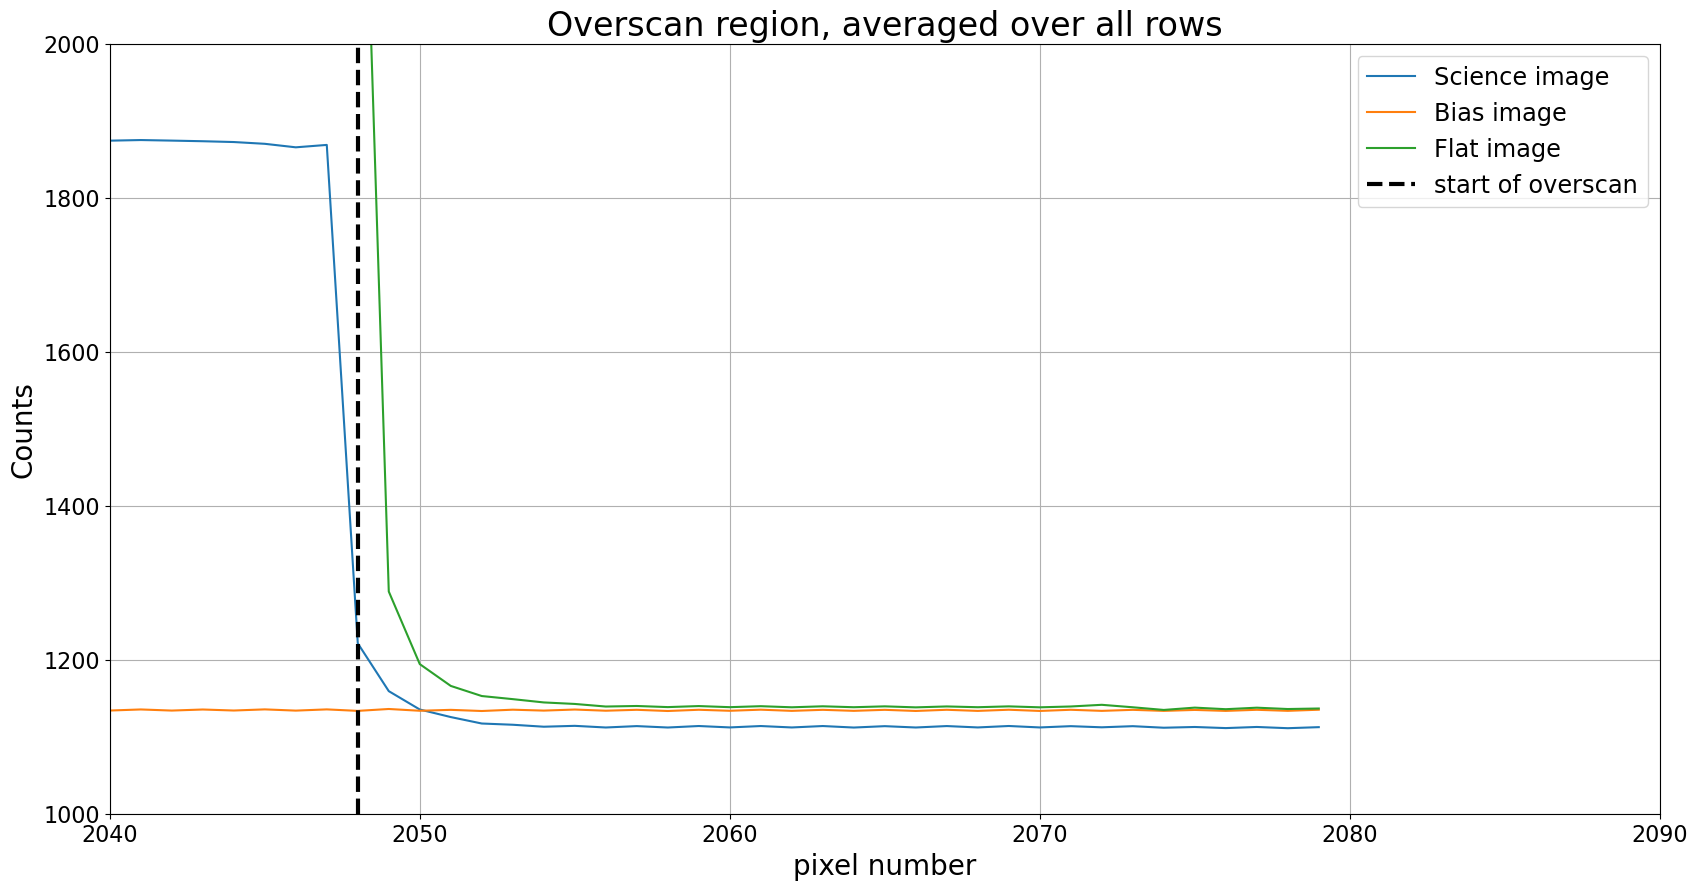

In [17]:
plt.figure(figsize=(20,10))
plt.plot(science_g_lfc.data.mean(axis=0), label='Science image')
plt.plot(bias_lfc.data.mean(axis=0), label='Bias image')
plt.plot(flat_g_lfc.data.mean(axis=0), label='Flat image')
plt.grid()

plt.axvline(x=2048, color='black', linewidth=3, linestyle='dashed', label='start of overscan')
plt.legend()

plt.ylim(1000, 2000)
plt.xlim(2040, 2090)
plt.xlabel('pixel number')
plt.ylabel('Counts')
plt.title('Overscan region, averaged over all rows')

## Discussion of example 1

**The count value is nearly uniform in the overscan region.**
<br>This is good; ideally the overscan is nearly uniform since the pixels are not illuminated.

*Na região de overscan (depois que estabiliza), os valores de counts são praticamente constantes para as três imagens (bias, science e flat).*

---

**Some light leaks from the imaging region into the overscan region.**
<br>This is clearest in the flat image, where the counts are much higher than the value to which they asymptote until at least pixel number 2055.

Though the FITS header indicates the overscan starts at pixel 2048, the useful part of the overscan (i.e. the part not contaminated by light) extends from pixel 2055 to the end.

*vazamento de luz é ruim porque header diz que o overscan começa em 2048, mas a região realmente útil é só de 2055 até o final (2079).*

---

**There is an offset between the science image and the other two images, and perhaps between the flat and bias images.**
<br> <u>This sort of variation is what overscan is intended to correct.</u> It could be that this one science image has a different overscan value (it was taken several hours after the flat image) or it could be that all science images have a different overscan value than other types of images.

Either way, subtracting overscan from each of the images allows for correction of these offsets.

*A imagem de science tem o nível de overscan uns ~20 counts mais baixo que o bias e o flat. Se você subtrair o overscan de cada imagem individualmente, esse offset some.*

---

**Dark current in this camera is essentially zero so the overscan is measuring bias.**
<br>To be clear, this isn’t apparent from the graph above, but cryogenically cooled cameras have negligible dark current.

*Nesta câmera, a dark current é tão pequena que pode ser ignorada. Então o que o overscan está medindo é basicamente só o bias e o ruído de leitura.*

## What happens if you don’t use the overscan?

Nothing particularly bad. In the specific case above, ignoring the overscan will shift the background level in the science image by roughly 20 counts, since the difference between the overscan region of the science image is lower than the overscan in the other images by roughly 20 counts. If, before doing science, the background of those images is subtracted, then this shift should be removed with the background.

*Nada de ruim aconteceria, a imagem de science ficaria com o background deslocado em uns 20 counts. Mas se for subtrair o background da imagem de science depois (o que é padrão em redução de dados), esse deslocamento acaba sendo removido junto.*

## Conclusion for case 1

The overscan is useful, <u>but the usable overscan region extends from 2055 to the end of the chip rather than from 2048 to end of the chip as the FITS header claims.</u> Put a little differently, the <u>appropriate <span style="color: #d62495"> BIASSEC.</span> . for these images is <span style="color: #d62495"> [2056:2080,1:4127].</span> </u> (Note that FITS starts numbering at 1 instead of 0, so 2055 in Python is 2056 in FITS notation.)

If the science you are using requires knowing the counts to a precision of a count or two, and modeling the background in the science image isn’t an option, consider using the overscan.

# Case 2: Thermo-electrically cooled Apogee Aspen CG16M

This is a low-end, research-grade CCD sold by Andor. Basic information is [here](https://andor.oxinst.com/assets/uploads/documents/Andor/apogee/Apogee_Aspen_CG16M_Specifications.pdf), though you need to track down the description of the sensor chip, [KAF-16803 CCD](https://www.onsemi.com/pdf/datasheet/kaf-16803-d.pdf) to find out that the overscan region of this 4096 × 4096 pixel camera extends from pixel 4097 to 4109 along one of the directions.

In [22]:
therma_path = Path('example-thermo-electric')
kelt = CCDData.read(therma_path / 'kelt-16-b-S001-R001-C084-r.fit', unit='adu')
dark1000 = CCDData.read('dark-test-0002d1000.fit.bz2', unit='adu')
flat = CCDData.read(therma_path / 'AutoFlat-PANoRot-r-Bin1-006.fit', unit='adu')
master = CCDData.read('combined_bias_100_images.fit.bz2', unit='adu')

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


C:\Users\nynym\anaconda3\Lib\site-packages\astropy\wcs\wcs.py:806: FITSFixedWarning: 'datfix' made the change 'Set MJD-OBS to 58269.980359 from DATE-OBS'.
  warnings.warn(


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


C:\Users\nynym\anaconda3\Lib\site-packages\astropy\wcs\wcs.py:806: FITSFixedWarning: 'datfix' made the change 'Set MJD-OBS to 58269.954861 from DATE-OBS'.
  warnings.warn(


(900.0, 1300.0)

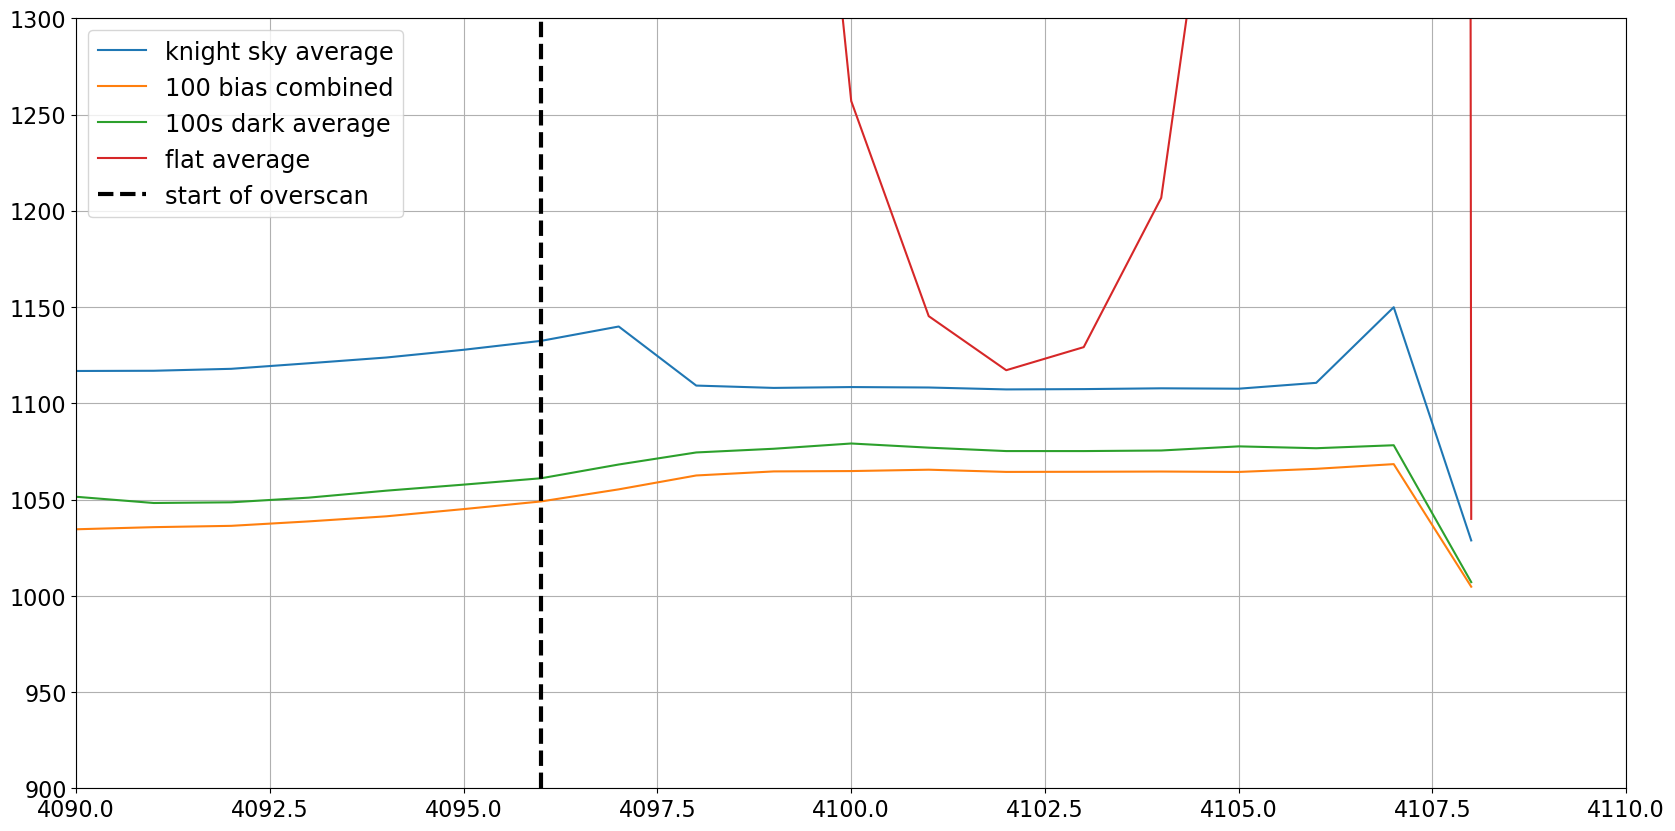

In [23]:
plt.figure(figsize=(20,10))

plt.plot(kelt.data.mean(axis=0), label='knight sky average')
plt.plot(master.data.mean(axis=0), label='100 bias combined')
plt.plot(dark1000.data.mean(axis=0), label='100s dark average')
plt.plot(flat.data.mean(axis=0), label='flat average')

plt.grid()
plt.axvline(x=4096, color='black', linewidth=3, linestyle='dashed', label='start of overscan')
plt.legend()
plt.xlim(4090, 4110)
plt.ylim(900, 1300)

## Discussion of Example 2

**Count values change quite a bit in the overscan region**
<br>This is clearest in the overscan for the flat. Not only is light leaking into the overscan, the overscan appears to be mostly light leakage. One pixel may be useful at best.

*Os counts mudam bastante dentro da região de overscan. No flat, o overscan parece ser basicamente vazamento de luz. Quase nenhum pixel do overscan é confiável.*

---

**Overscan includes dark current**
<br>The overscan for the dark image in the figure above is roughly 10 counts higher than the counts for the bias. The dark current for this camera is roughly 0.01 counts/pixel/second. For a 1000 second dark exposure, the expected dark counts are about 10, which is the difference seen in the graph.

*O overscan da imagem dark (1000 segundos) está cerca de 10 counts acima do overscan do bias, o overscan não é só bias — tem contribuição significativa de dark current.*

---

**There is an offset between the bias/dark and science/flat images**
<br>The offset in this camera is roughly 50 counts. It’s large enough that one ought to be hesitant to use the overscan for this camera.

*offset muito grande, existe uma diferença de aproximadamente 50 counts*

---

**The overscan counts are higher than the average bias counts**
<br>Note that for the bias image, counts increase up to the pixel where overscan starts and then level out. <u>It turns out that overscan counts are higher than the average of the bias counts,</u> so subtracting the overscan would lead to a bias image that is negative. This is another reason to be suspicious of the overscan region on this camera.

*Na imagem de bias, os counts aumentam até o pixel onde começa o overscan, e depois se estabilizam num valor mais alto do que a média da região iluminada.*

## Conclusion for case 2

Do not use the overscan in this case. There are serious issues with light leakage and large differences in the overscan counts between the bias and science images.

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Notes
  </span>
</h1>

- Overscan é uma região do chip CCD que está coberta — nunca recebe luz. É como uma "faixa escura" nas bordas da imagem.

- BIASSEC = palavra-chave no header do arquivo FITS que diz onde está a região de overscan na imagem. É o fabricante da câmera (ou o software de aquisição) que escreve isso no header quando a imagem é salva.

- [example-cryo-LFC (1)](https://github.com/astropy/ccd-reduction-and-photometry-guide/blob/ae5ec5f8cc73516faf1085c68a9fe1ecb33f4d23/notebooks/download_data.py#L80) & [example-thermo-electric (2)](https://github.com/astropy/ccd-reduction-and-photometry-guide/blob/ae5ec5f8cc73516faf1085c68a9fe1ecb33f4d23/notebooks/download_data.py#L86) tem que baixar (!python example-thermo-electric.py) caso queira que rode.

- Matplotlib [axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html) & [pyplot](https://matplotlib.org/stable/tutorials/pyplot.html).

- Lembrar que:
    - Nas conclusions for case 1: usar o overscan com a região correta: 2055 até o final do chip — não 2048 como o header diz.

---

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Links
  </span>
</h1>

https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://github.com/sh4rkNy/astropy-coisas/tree/main<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-08-Overscan.html

https://matplotlib.org/stable/users/index.html<br>